In [249]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym  #usado para manipulación simbólica de ecuaciones
from numpy.linalg import norm #útil en el control de errores en las iteraciones

In [252]:
#CREO UNA GRILLA CON DISTINTOS PUNTOS INICIALES
def generador_puntos_inciales(n):
  #r= extremos de la grilla
  puntos = []
  for x in np.linspace(-2,2,n):
    for y in np.linspace(-2,2,n):
      puntos.append([x,y])
  return puntos

#DEEFINO FUNCION DE EJECUCION
def crear_fractales(n):
  grilla = generador_puntos_inciales(n)

  real , imaginaria , color , iteraciones= [],  [],  [],  []

  #Aplico el metodo de newton a cada punto de la grilla
  for x0 in grilla:
      solucion = sistema_newton(F,J,x0)

      #Voy concadenando los resultado, forma que encontre para poder graficar
      real += solucion[0]
      imaginaria += solucion[1]
      color += solucion[2]
      iteraciones += solucion [3]

  return real, imaginaria, color, iteraciones

# IMPLEMENTACIÓN DEL MÉTODO PARA LA FUNCIÓN $$f(z)= z^3 -1 $$

In [253]:
#DEFINO VECTOR DE FUNCIONES
def F(x0):
    x,y = x0
    #transforma a funciones
    f1 = x**3 - 3*x*y**2 - 1
    f2 = 3*x**2*y - y**3

    return np.array([f1,f2])

#DEFINO MATRIZ JACOBIANA
def J(x0):
    x = sym.Symbol('x')
    y = sym.Symbol('y')

    f1 = sym.sympify(x**3 - 3*x*y**2 - 1)
    f2 = sym.sympify(3*x**2*y - y**3)

    #calculo la derivadas parciales
    df1x = sym.diff(f1, x)
    df1y = sym.diff(f1, y)
    df2x = sym.diff(f2, x)
    df2y = sym.diff(f2, y)

    # Evaluar el Jacobiano en el punto x0
    J = np.array([
          [df1x.subs({x: x0[0], y: x0[1]}), df1y.subs({x: x0[0], y: x0[1]})],
          [df2x.subs({x: x0[0], y: x0[1]}), df2y.subs({x: x0[0], y: x0[1]})]
          ] , dtype= float)
    return J

#METODO DE NEWTON
def sistema_newton(F,J,x0,max_iter=100,tol=1e-6):

    x = np.array(x0, dtype=float)

    iteraciones = [0]
    xn, yn = [x0[0]], [x0[1]]
    color = []

    for k in range(max_iter):

        b = F(x)
        A = J(x)

        #resolver sistema de ecuaciones
        x_i = np.linalg.solve(A, -b)

        #Actualizamos el punto
        x = x + x_i
        xn.append(x[0])
        yn.append(x[1])
        iteraciones = [k+1] + iteraciones

        # Error
        if norm(np.array(x)-[1,0],2) < tol:
            break
        if norm(np.array(x)-[-0.5,0.8660254],2) < tol:
            break
        elif norm(np.array(x)-[-0.5,-0.8660254],2) < tol:
            break

    # Coloreo de puntos segun la raiz
    if norm(np.array(x)-[1,0],2) < tol:
        c = [0 for j in xn]
    elif norm(np.array(x)-[-0.5,0.8660254],2) < tol:
        c = [1 for j in xn]
    elif norm(np.array(x)-[-0.5,-0.8660254],2) < tol:
        c = [2 for j in xn]
    else:
        c = [3 for j in xn]

    return xn,yn,c,iteraciones

In [254]:
#CREAMOS FRACTALES...
real ,imaginaria ,color, iteraciones = crear_fractales(200)

print(f"Con un error del 1e-6, el máximo numero de iteraciones fue: {(max(iteraciones))}")

Con un error del 1e-6, el máximo numero de iteraciones fue: 38


# GRÁFICOS :
1. REGIONES DE CONVERGENCIA
2. CANTIDAD DE ITERACIONES

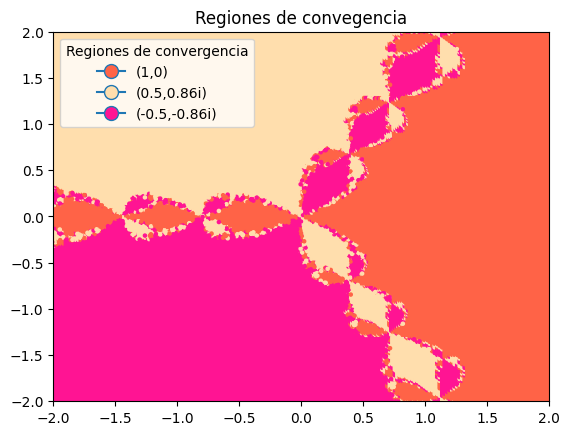

In [255]:
#GRAFICAMOS

#Mostramos Regiones de convergencia
fig, ax = plt.subplots()
ax.set_title('Regiones de convegencia')
ax.set_xlim(xmax=2, xmin=-2)
ax.set_ylim(ymax=2, ymin=-2)

# Colores específicos para cada raíz
color_map = {
    0: 'tomato',
    1: 'navajowhite',
    2: 'deeppink',
    3: 'black'    # Color para No converge
}

scatter = ax.scatter(real, imaginaria, c=[color_map[c] for c in color], s=5)

id_colores = np.unique(color)
labels = {0: '(1,0)', 1: '(0.5,0.86i)', 2: '(-0.5,-0.86i)', 3: 'No converge'}

# Referencia de regiones de convergencia
elemento_leyenda = [plt.Line2D([0], [0], marker='o',markerfacecolor=color_map[category], markersize=10,label=labels[category])
                              for category in id_colores]

# Crea la leyenda
ax.legend(handles=elemento_leyenda[:10], title='Regiones de convergencia',loc = 'upper left')

plt.show()

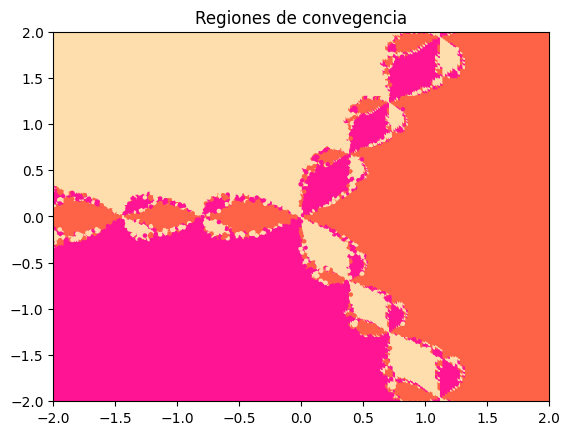

In [256]:
#GRAFICAMOS

#Mostramos Regiones de convergencia
fig, ax = plt.subplots()
ax.set_title('Regiones de convegencia')
ax.set_xlim(xmax=2, xmin=-2)
ax.set_ylim(ymax=2, ymin=-2)

# Colores específicos para cada raíz
color_map = {
    0: 'tomato',
    1: 'navajowhite',
    2: 'deeppink',
    3: 'black'    # Color para No converge
}

scatter = ax.scatter(real, imaginaria, c=[color_map[c] for c in color], s=5)
plt.show()

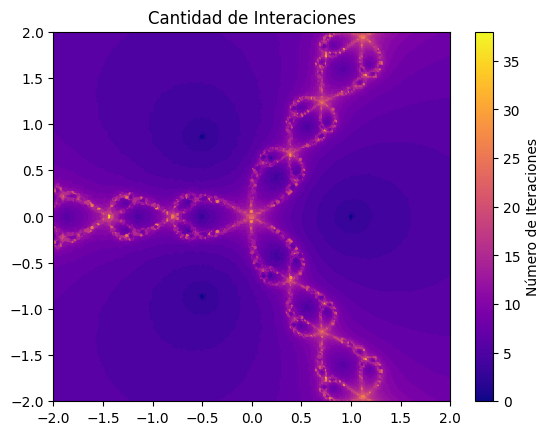

In [257]:
#GRAFICAMOS

#Mostramos Cantidad de Iteraciones
fig, ax1 = plt.subplots()
ax1.set_title('Cantidad de Interaciones')
ax1.set_xlim(xmax=2, xmin=-2)
ax1.set_ylim(ymax=2, ymin=-2)

scatter = ax1.scatter(real, imaginaria, c=iteraciones, s=2,cmap='plasma')

# Agregar la barra de colores
cbar = plt.colorbar(scatter, ax=ax1, label='Número de Iteraciones')

plt.show()

# IMPLEMENTACIÓN DEL MÉTODO PARA $$f(z)= z^n - 1 \quad ,n=4,5 $$

# $$f(x)= z^4 - 1$$

In [259]:
#DEFINO VECTOR DE FUNCIONES
def F(x0):
    x,y = x0
    #transforma a funciones
    f1 = x**4-6*x**2*y**2+y**4-1
    f2 = 4*x**3*y-4*x*y**3

    return np.array([f1,f2])

#DEFINO MATRIZ JACOBIANA
def J(x0):
    x = sym.Symbol('x')
    y = sym.Symbol('y')

    f1 = sym.sympify(x**4-6*x**2*y**2+y**4-1)
    f2 = sym.sympify(4*x**3*y-4*x*y**3)

    #calculo la derivadas parciales
    df1x = sym.diff(f1, x)
    df1y = sym.diff(f1, y)
    df2x = sym.diff(f2, x)
    df2y = sym.diff(f2, y)

    # Evaluar el Jacobiano en el punto x0
    J = np.array([
          [df1x.subs({x: x0[0], y: x0[1]}), df1y.subs({x: x0[0], y: x0[1]})],
          [df2x.subs({x: x0[0], y: x0[1]}), df2y.subs({x: x0[0], y: x0[1]})]
          ] , dtype= float)
    return J

#METODO DE NEWTON
def sistema_newton(F,J,x0,max_iter=70,tol=1e-4):

    x = np.array(x0, dtype=float)

    iteraciones = [0]
    xn, yn = [x0[0]], [x0[1]]
    color = []

    for k in range(max_iter):

        b = F(x)
        A = J(x)

        #resuelvo sistema de ecuacion
        x_i = np.linalg.solve(A, -b)

        #Actualizamos el punto
        x = x + x_i
        xn.append(x[0])
        yn.append(x[1])
        iteraciones = [k+1] + iteraciones

        # Error
        if norm(np.array(x)-[1,0],2) < tol:
            break
        if norm(np.array(x)-[-1,0],2) < tol:
            break
        elif norm(np.array(x)-[0,1],2) < tol:
            break
        elif norm(np.array(x)-[0,-1],2) < tol:
            break

    # Coloreo de puntos segun la raiz
    if norm(np.array(x)-[1,0],2) < tol:
        c = [0 for j in xn]
    elif norm(np.array(x)-[-1,0],2) < tol:
        c = [1 for j in xn]
    elif norm(np.array(x)-[0,1],2) < tol:
        c = [2 for j in xn]
    elif norm(np.array(x)-[0,-1],2) < tol:
        c = [3 for j in xn]
    else:
        c = [4 for j in xn]

    return xn,yn,c,iteraciones

In [260]:
#CREAMOS FRACTALES...
real ,imaginaria ,color, iteraciones = crear_fractales(150)

print(f"Con un error del 1e-4, el máximo numero de iteraciones fue: {(max(iteraciones))}")

Con un error del 1e-4, el máximo numero de iteraciones fue: 70


# GRÁFICOS :
1. REGIONES DE CONVERGENCIA
2. CANTIDAD DE ITERACIONES

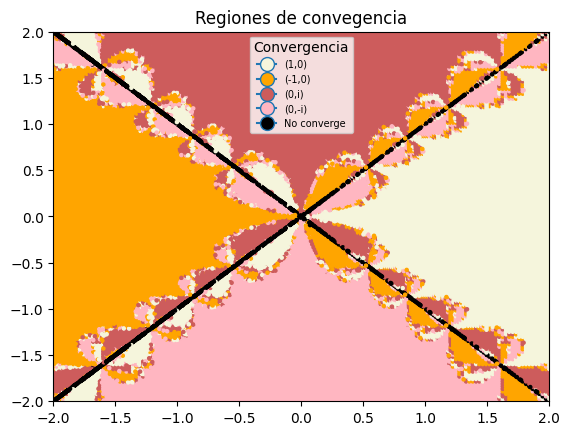

In [261]:
#GRAFICAMOS

#Mostramos Regiones de convergencia
fig, ax = plt.subplots()
ax.set_title('Regiones de convegencia')
ax.set_xlim(xmax=2, xmin=-2)
ax.set_ylim(ymax=2, ymin=-2)

# Colores específicos para cada raíz
color_map = {
    0: 'beige',
    1: 'orange',
    2: 'indianred',
    3: 'lightpink' ,
    4: 'black'    # Color para No converge
}

scatter = ax.scatter(real, imaginaria, c=[color_map[c] for c in color], s=5)

id_colores = np.unique(color)
labels = {0: '(1,0)', 1: '(-1,0)', 2: '(0,i)', 3: '(0,-i)', 4:'No converge'}

# Referencia de regiones de convergencia
elemento_leyenda = [plt.Line2D([0], [0], marker='o',markerfacecolor=color_map[category], markersize=10,label=labels[category])
                              for category in id_colores]

# Crea la leyenda
ax.legend(handles=elemento_leyenda[:10], fontsize=7, title='Convergencia', loc='upper center')

plt.show()

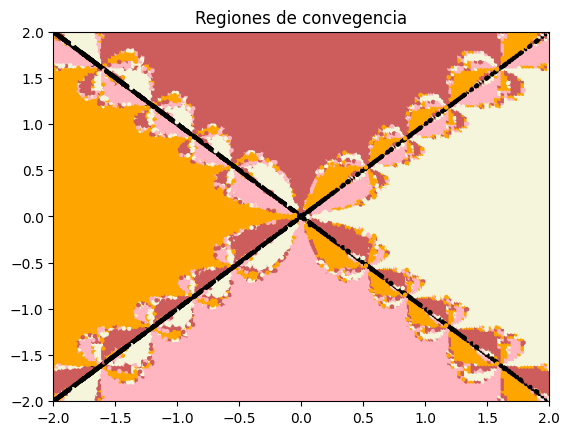

In [262]:
#GRAFICAMOS

#Mostramos Regiones de convergencia
fig, ax = plt.subplots()
ax.set_title('Regiones de convegencia')
ax.set_xlim(xmax=2, xmin=-2)
ax.set_ylim(ymax=2, ymin=-2)

# Colores específicos para cada raíz
color_map = {
    0: 'beige',
    1: 'orange',
    2: 'indianred',
    3: 'lightpink' ,
    4: 'black'    # Color para No converge
}

scatter = ax.scatter(real, imaginaria, c=[color_map[c] for c in color], s=5)
plt.show()

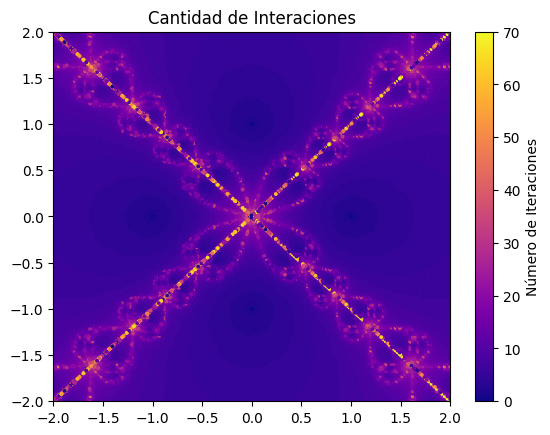

In [263]:
#GRAFICAMOS

#Mostramos Cantidad de Iteraciones
fig, ax1 = plt.subplots()
ax1.set_title('Cantidad de Interaciones')
ax1.set_xlim(xmax=2, xmin=-2)
ax1.set_ylim(ymax=2, ymin=-2)

scatter = ax1.scatter(real, imaginaria, c=iteraciones, s=3,cmap='plasma')

# Agregar la barra de colores
cbar = plt.colorbar(scatter, ax=ax1, label='Número de Iteraciones')

plt.show()

# $$f(z)= z^5 -1$$

In [264]:
def F(x0):
    x,y = x0
    #transforma a funciones
    f1 = x**5-10*x**3*y**2+5*x*y**4-1
    f2 = 5*x**4*y-10*x**2*y**3+y**5

    return np.array([f1,f2])

def J(x0):
    x = sym.Symbol('x')
    y = sym.Symbol('y')

    f1 = sym.sympify(x**5-10*x**3*y**2+5*x*y**4-1)
    f2 = sym.sympify(5*x**4*y-10*x**2*y**3+y**5)

    #calculo la derivadas parciales
    df1x = sym.diff(f1, x)
    df1y = sym.diff(f1, y)
    df2x = sym.diff(f2, x)
    df2y = sym.diff(f2, y)

    # Evaluar el Jacobiano en el punto x0
    J = np.array([
          [df1x.subs({x: x0[0], y: x0[1]}), df1y.subs({x: x0[0], y: x0[1]})],
          [df2x.subs({x: x0[0], y: x0[1]}), df2y.subs({x: x0[0], y: x0[1]})]
                  ] , dtype= float)
    return J

#METODO DE NEWTON
def sistema_newton(F,J,x0,max_iter=100,tol=1e-4):

    k = 1
    x = np.array(x0, dtype=float)

    iteraciones = [0]
    xn, yn = [x0[0]], [x0[1]]
    color = []

    for k in range(max_iter):

        b = F(x)
        A = J(x)

        #Resuelvo sistema de acuaciones
        x_i = np.linalg.solve(A, -b)

        #Actualizamos el punto
        x = x + x_i
        xn.append(x[0])
        yn.append(x[1])
        iteraciones = [k+1] + iteraciones

        # Error
        if norm(np.array(x)-[1,0],2) < tol:
            break
        elif norm(np.array(x)-[np.cos(2 * np.pi / 5), np.sin(2 * np.pi / 5)],2) < tol:
            break
        elif norm(np.array(x)-[np.cos(4 * np.pi / 5), np.sin(4 * np.pi / 5)],2) < tol:
            break
        elif norm(np.array(x)-[np.cos(6 * np.pi / 5), np.sin(6 * np.pi / 5)],2) < tol:
            break
        elif norm(np.array(x)-[np.cos(8 * np.pi / 5), np.sin(8 * np.pi / 5)],2) < tol:
            break


    # Coloreo de puntos segun la raiz
    if norm(np.array(x)-[1,0],2) < tol:
        c = [0 for j in xn]
    elif norm(np.array(x)-[np.cos(2 * np.pi / 5), np.sin(2 * np.pi / 5)],2) < tol:
        c = [1 for j in xn]
    elif norm(np.array(x)-[np.cos(4 * np.pi / 5), np.sin(4 * np.pi / 5)],2) < tol:
        c = [2 for j in xn]
    elif norm(np.array(x)-[np.cos(6 * np.pi / 5), np.sin(6 * np.pi / 5)],2) < tol:
        c = [3 for j in xn]
    elif norm(np.array(x)-[np.cos(8 * np.pi / 5), np.sin(8 * np.pi / 5)],2) < tol:
        c = [4 for j in xn]
    else:
        c = [5 for j in xn]

    return xn,yn,c,iteraciones

In [265]:
#CREAMOS FRACTALES...
real ,imaginaria ,color, iteraciones= crear_fractales(100)
print(f'Con un error de 1e-4, el maximo numero de iteraciones fue:{(max(iteraciones))} ')

Con un error de 1e-4, el maximo numero de iteraciones fue:84 


# GRÁFICOS :
1. REGIONES DE CONVERGENCIA
2. CANTIDAD DE ITERACIONES

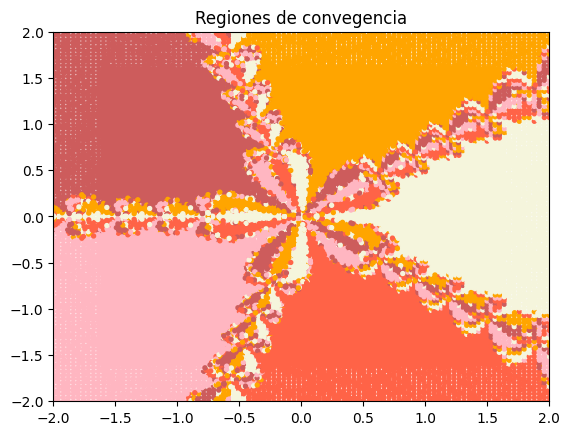

In [267]:
#GRAFICAMOS

#Mostramos Regiones de convergencia
fig, ax = plt.subplots()
ax.set_title('Regiones de convegencia')
ax.set_xlim(xmax=2, xmin=-2)
ax.set_ylim(ymax=2, ymin=-2)

# Colores específicos para cada raíz
color_map = {
    0: 'beige',
    1: 'orange',
    2: 'indianred',
    3: 'lightpink' ,
    4: 'tomato',
    6: 'black'# Color para No converge
}

scatter = ax.scatter(real, imaginaria, c=[color_map[c] for c in color], s=8)
plt.show()

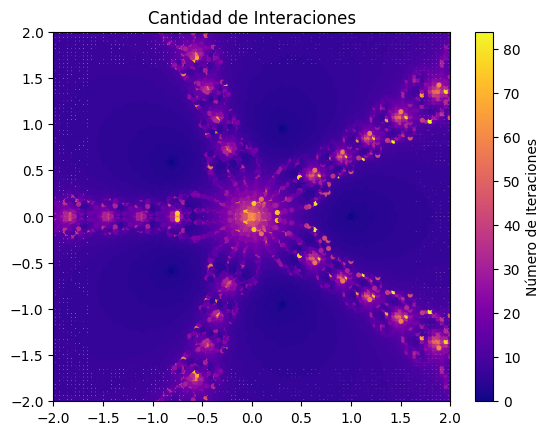

In [272]:
#GRAFICAMOS

#Mostramos Cantidad de Iteraciones
fig, ax1 = plt.subplots()
ax1.set_title('Cantidad de Interaciones')
ax1.set_xlim(xmax=2, xmin=-2)
ax1.set_ylim(ymax=2, ymin=-2)

scatter = ax1.scatter(real, imaginaria, c=iteraciones, s=7,cmap='plasma')

# Agregar la barra de colores
cbar = plt.colorbar(scatter, ax=ax1, label='Número de Iteraciones')

plt.show()

#IMPLEMENTACION DE $$f(z) = z^3-2z+2$$

In [275]:
#CREO UNA GRILLA CON DISTINTOS PUNTOS INICIALES
def generador_puntos_inciales(n):
  #r= extremos de la grilla
  puntos = []
  for x in np.linspace(-4,4,n):
    for y in np.linspace(-4,4,n):
      puntos.append([x,y])
  return puntos
#DEFINO VECTOR DE FUNCIONES
def F(x0):
    x,y = x0
    #transforma a funciones
    f1 = x**3-2*x-3*x*y**2+2
    f2 = 3*x**2*y-y**3-2*y

    return np.array([f1,f2])

#DEFINO MATRIZ JACOBIANA
def J(x0):
    x = sym.Symbol('x')
    y = sym.Symbol('y')

    f1 = sym.sympify(x**3-2*x-3*x*y**2+2)
    f2 = sym.sympify(3*x**2*y-y**3-2*y)

    #calculo la derivadas parciales
    df1x = sym.diff(f1, x)
    df1y = sym.diff(f1, y)
    df2x = sym.diff(f2, x)
    df2y = sym.diff(f2, y)

    # Evaluar el Jacobiano en el punto x0
    J = np.array([
          [df1x.subs({x: x0[0], y: x0[1]}), df1y.subs({x: x0[0], y: x0[1]})],
          [df2x.subs({x: x0[0], y: x0[1]}), df2y.subs({x: x0[0], y: x0[1]})]
          ] , dtype= float)
    return J

#METODO DE NEWTON
def sistema_newton(F,J,x0,max_iter=100,tol=1e-3):

    x = np.array(x0, dtype=float)

    iteraciones = [0]
    xn, yn = [x0[0]], [x0[1]]
    color = []

    for k in range(max_iter):

        b = F(x)
        A = J(x)

        #resolver sistema de ecuaciones
        x_i = np.linalg.solve(A, -b)

        #Actualizamos el punto
        x = x + x_i
        xn.append(x[0])
        yn.append(x[1])
        iteraciones = [k+1] + iteraciones

        # Error
        if norm(np.array(x)-[-1.7693,0],2) < tol:
            break
        elif norm(np.array(x)-[0.88465,-0.58974],2) < tol:
            break
        elif norm(np.array(x)-[0.88465,0.58974],2) < tol:
            break

    # Coloreo de puntos segun la raiz
    if norm(np.array(x)-[-1.7693,0],2) < tol:
        c = [0 for j in xn]
    elif norm(np.array(x)-[0.88465,-0.58974],2) < tol:
        c = [1 for j in xn]
    elif norm(np.array(x)-[0.88465,0.58974],2) < tol:
        c = [2 for j in xn]
    else:
        c = [3 for j in xn]

    return xn,yn,c,iteraciones

In [276]:
#CREAMOS FRACTALES...
real ,imaginaria ,color, iteraciones= crear_fractales(150)
print(f'Con un error de 1e-3, el maximo numero de iteraciones fue:{(max(iteraciones))} ')

Con un error de 1e-3, el maximo numero de iteraciones fue:100 


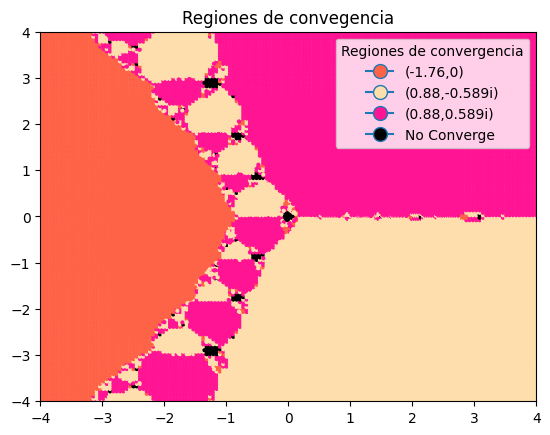

In [277]:
#GRAFICAMOS

#Mostramos Regiones de convergencia
fig, ax = plt.subplots()
ax.set_title('Regiones de convegencia')
ax.set_xlim(xmax=4, xmin=-4)
ax.set_ylim(ymax=4, ymin=-4)

# Colores específicos para cada raíz
color_map = {
    0: 'tomato',
    1: 'navajowhite',
    2: 'deeppink',
    3: 'black'    # Color para No converge
}

scatter = ax.scatter(real, imaginaria, c=[color_map[c] for c in color], s=4)

id_colores = np.unique(color)
labels = {0: '(-1.76,0)', 1: '(0.88,-0.589i)', 2: '(0.88,0.589i)', 3: 'No Converge'}

# Referencia de regiones de convergencia
elemento_leyenda = [plt.Line2D([0], [0], marker='o',markerfacecolor=color_map[category], markersize=10,label=labels[category])
                              for category in id_colores]

# Crea la leyenda
ax.legend(handles=elemento_leyenda[:10], title='Regiones de convergencia',loc='upper right')
plt.show()

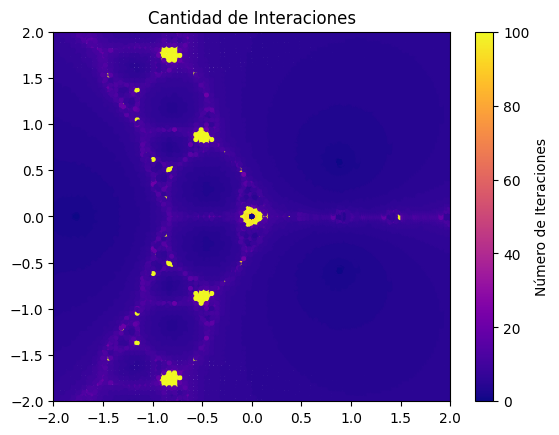

In [278]:
#GRAFICAMOS

#Mostramos Cantidad de Iteraciones
fig, ax1 = plt.subplots()
ax1.set_title('Cantidad de Interaciones')
ax1.set_xlim(xmax=2, xmin=-2)
ax1.set_ylim(ymax=2, ymin=-2)

scatter = ax1.scatter(real, imaginaria, c=iteraciones, s=7,cmap='plasma')

# Agregar la barra de colores
cbar = plt.colorbar(scatter, ax=ax1, label='Número de Iteraciones')

plt.show()